In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
data  = fetch_california_housing()
X_all = data.data[:, 0].reshape(-1, 1)
y_all = data.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42
)

scaler_x  = StandardScaler()
scaler_y  = StandardScaler()
X_train_s = scaler_x.fit_transform(X_train_full)
X_test_s  = scaler_x.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train_full.reshape(-1,1)).flatten()
y_test_s  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

In [3]:
def poly_features(X, degree):
    return np.hstack([X**d for d in range(0, degree + 1)])

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gradient_descent_ridge(X, y, lr=0.01, iters=1000, lam=0.0):
    m, n  = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(iters):
        pred  = X @ theta
        grad  = (2/m) * X.T @ (pred - y) + (2 * lam / m) * theta
        grad[0] -= (2 * lam / m) * theta[0]
        theta = theta - lr * grad
        losses.append(mse(y, pred))
    return theta, losses

def gradient_descent_lasso(X, y, lr=0.005, iters=1000, lam=0.0):
    m, n  = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(iters):
        pred    = X @ theta
        grad    = (2/m) * X.T @ (pred - y)
        l1_grad = lam * np.sign(theta)
        l1_grad[0] = 0
        theta = theta - lr * (grad + l1_grad)
        losses.append(mse(y, pred))
    return theta, losses

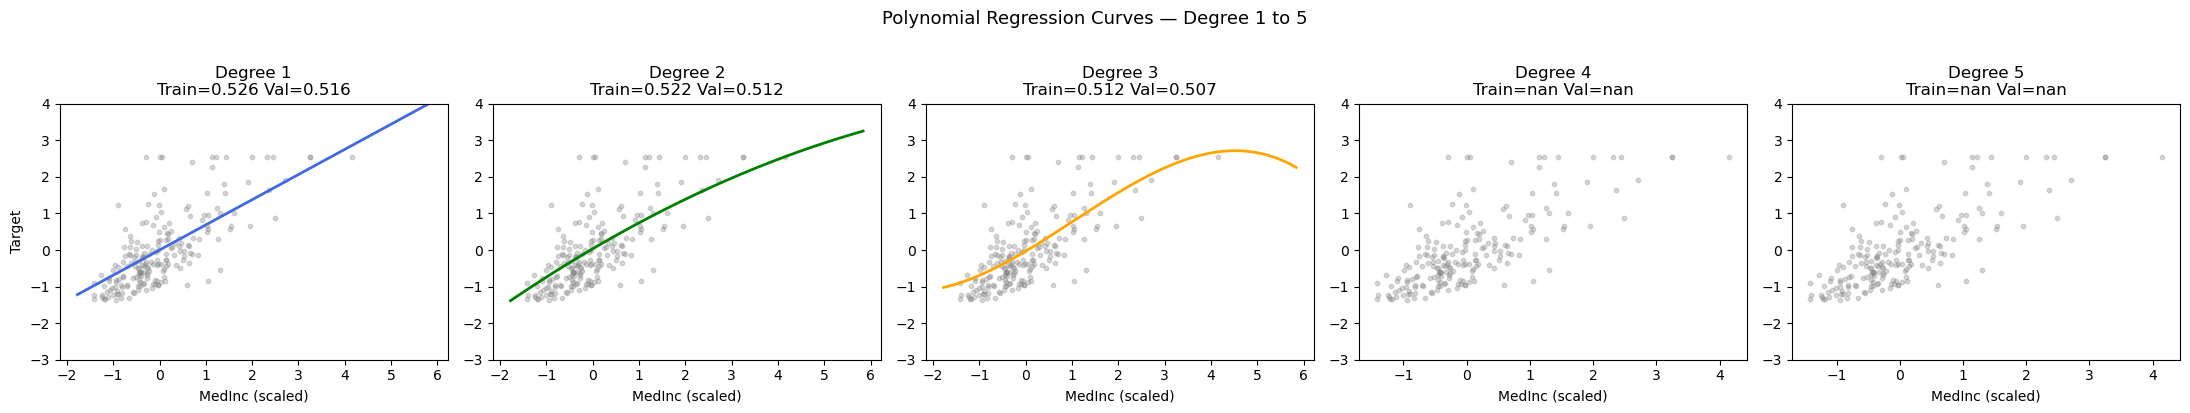

In [4]:
# Regression curves for degree 1 to 5
degrees      = [1, 2, 3, 4, 5]
colors_deg   = ['royalblue', 'green', 'orange', 'crimson', 'purple']
train_errors = []
val_errors   = []

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, d in enumerate(degrees):
    X_tr_poly  = poly_features(X_train_s, d)
    X_val_poly = poly_features(X_test_s,  d)
    theta, _   = gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=0.0)

    tr_err  = mse(y_train_s, X_tr_poly  @ theta)
    val_err = mse(y_test_s,  X_val_poly @ theta)
    train_errors.append(tr_err)
    val_errors.append(val_err)

    x_line      = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
    y_line      = poly_features(x_line, d) @ theta

    axes[i].scatter(X_train_s[:200], y_train_s[:200], alpha=0.3, s=10, color='gray')
    axes[i].plot(x_line, y_line, color=colors_deg[i], linewidth=2)
    axes[i].set_title(f'Degree {d}\nTrain={tr_err:.3f} Val={val_err:.3f}')
    axes[i].set_xlabel('MedInc (scaled)')
    axes[i].set_ylim(-3, 4)

axes[0].set_ylabel('Target')
plt.suptitle('Polynomial Regression Curves — Degree 1 to 5', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

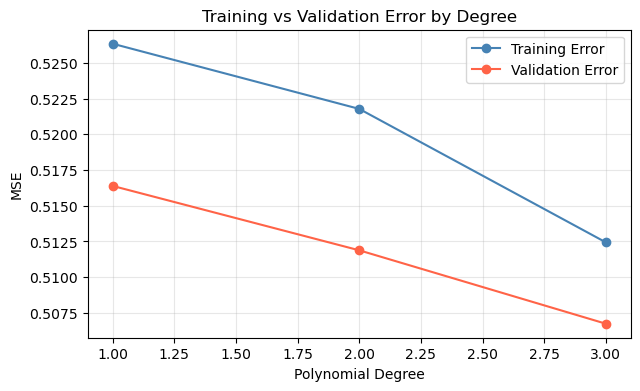

In [5]:
# Training vs Validation error by degree
plt.figure(figsize=(7, 4))
plt.plot(degrees, train_errors, 'o-', color='steelblue', label='Training Error')
plt.plot(degrees, val_errors,   'o-', color='tomato',    label='Validation Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Training vs Validation Error by Degree')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

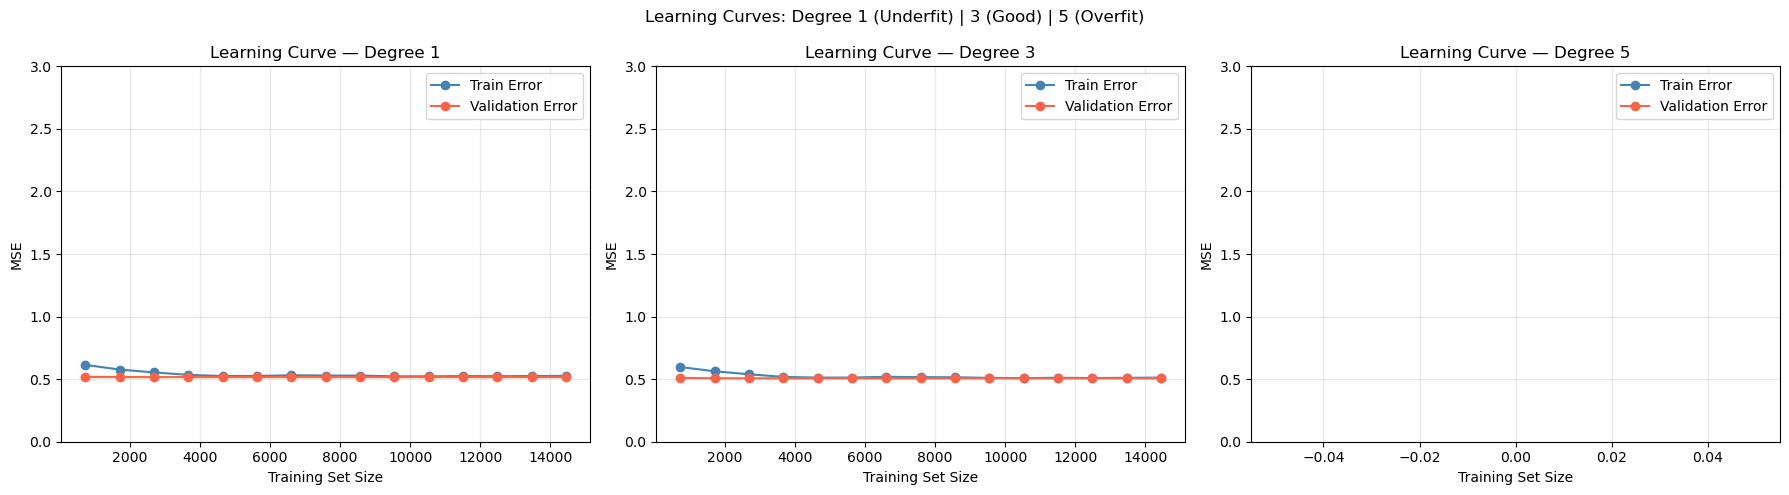

In [6]:
# Learning curves — error vs training set size
train_sizes = np.linspace(0.05, 1.0, 15)
fig, axes   = plt.subplots(1, 3, figsize=(18, 5))

for ax, d in zip(axes, [1, 3, 5]):
    tr_curve, val_curve, sizes = [], [], []
    for frac in train_sizes:
        n   = max(int(frac * len(X_train_s)), d + 2)
        Xtr = poly_features(X_train_s[:n], d)
        Xva = poly_features(X_test_s,      d)
        ytr = y_train_s[:n]
        theta, _ = gradient_descent_ridge(Xtr, ytr, lr=0.005, iters=1000, lam=0.0)
        tr_curve.append(mse(ytr,      Xtr @ theta))
        val_curve.append(mse(y_test_s, Xva @ theta))
        sizes.append(n)

    ax.plot(sizes, tr_curve,  'o-', color='steelblue', label='Train Error',      linewidth=1.5)
    ax.plot(sizes, val_curve, 'o-', color='tomato',    label='Validation Error',  linewidth=1.5)
    ax.set_title(f'Learning Curve — Degree {d}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 3)

plt.suptitle('Learning Curves: Degree 1 (Underfit) | 3 (Good) | 5 (Overfit)', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
print('Degree 1 → Underfitting : high train + val error (high bias, low variance)')
print('Degree 3 → Good fit     : both errors low and close to each other')
print('Degree 5 → Overfitting  : low train error, high val error (low bias, high variance)')

Degree 1 → Underfitting : high train + val error (high bias, low variance)
Degree 3 → Good fit     : both errors low and close to each other
Degree 5 → Overfitting  : low train error, high val error (low bias, high variance)


# Part 2 — Regularization

Lambda       Train Loss    ||theta||
------------------------------------
0                   nan          nan
0.01                nan          nan
0.1                 nan          nan
1                   nan          nan
10                  nan          nan


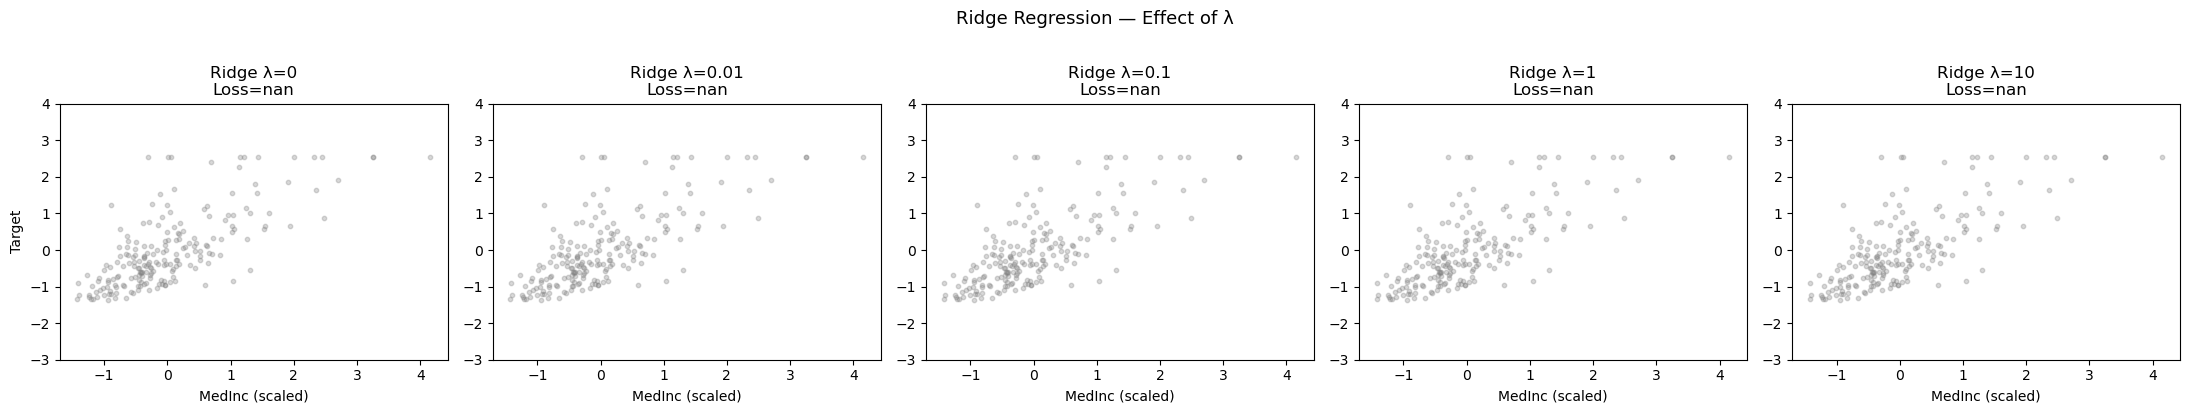

In [8]:
# Ridge Regression for lambda = {0, 0.01, 0.1, 1, 10}
lambdas      = [0, 0.01, 0.1, 1, 10]
colors_lam   = ['royalblue', 'green', 'orange', 'crimson', 'purple']
degree_ridge = 4

X_tr_poly  = poly_features(X_train_s, degree_ridge)
X_val_poly = poly_features(X_test_s,  degree_ridge)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

print(f"{'Lambda':<10} {'Train Loss':>12} {'||theta||':>12}")
print('-'*36)

for i, lam in enumerate(lambdas):
    theta, losses = gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    print(f"{lam:<10} {losses[-1]:>12.5f} {np.linalg.norm(theta[1:]):>12.5f}")

    x_line = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
    y_line = poly_features(x_line, degree_ridge) @ theta

    axes[i].scatter(X_train_s[:200], y_train_s[:200], alpha=0.3, s=10, color='gray')
    axes[i].plot(x_line, y_line, color=colors_lam[i], linewidth=2)
    axes[i].set_title(f'Ridge λ={lam}\nLoss={losses[-1]:.3f}')
    axes[i].set_xlabel('MedInc (scaled)')
    axes[i].set_ylim(-3, 4)

axes[0].set_ylabel('Target')
plt.suptitle('Ridge Regression — Effect of λ', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Lambda       Train Loss    ||theta||  Zero params
--------------------------------------------------
0                   nan          nan            0
0.01                nan          nan            0
0.1                 nan          nan            0
1                   nan          nan            0
10                  nan          nan            0


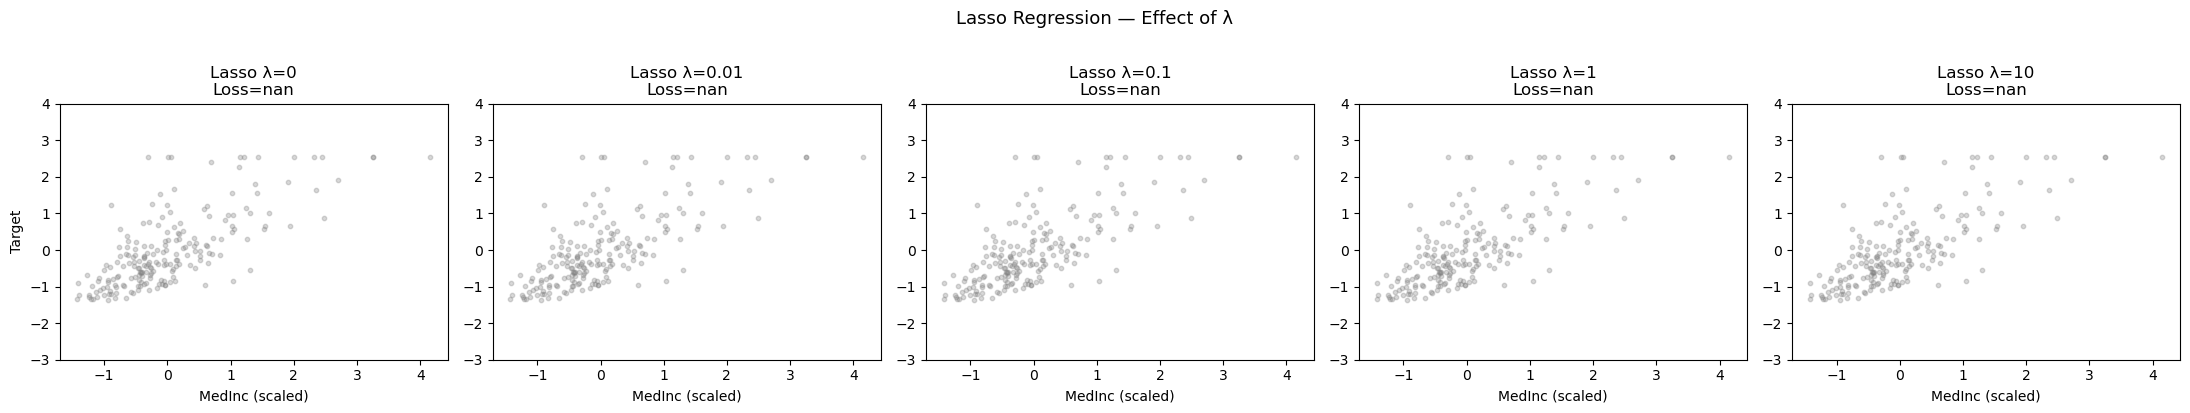

In [9]:
# Lasso Regression
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

print(f"{'Lambda':<10} {'Train Loss':>12} {'||theta||':>12} {'Zero params':>12}")
print('-'*50)

for i, lam in enumerate(lambdas):
    theta, losses = gradient_descent_lasso(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    zero_params   = np.sum(np.abs(theta[1:]) < 1e-3)
    print(f"{lam:<10} {losses[-1]:>12.5f} {np.linalg.norm(theta[1:]):>12.5f} {zero_params:>12}")

    x_line = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
    y_line = poly_features(x_line, degree_ridge) @ theta

    axes[i].scatter(X_train_s[:200], y_train_s[:200], alpha=0.3, s=10, color='gray')
    axes[i].plot(x_line, y_line, color=colors_lam[i], linewidth=2)
    axes[i].set_title(f'Lasso λ={lam}\nLoss={losses[-1]:.3f}')
    axes[i].set_xlabel('MedInc (scaled)')
    axes[i].set_ylim(-3, 4)

axes[0].set_ylabel('Target')
plt.suptitle('Lasso Regression — Effect of λ', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

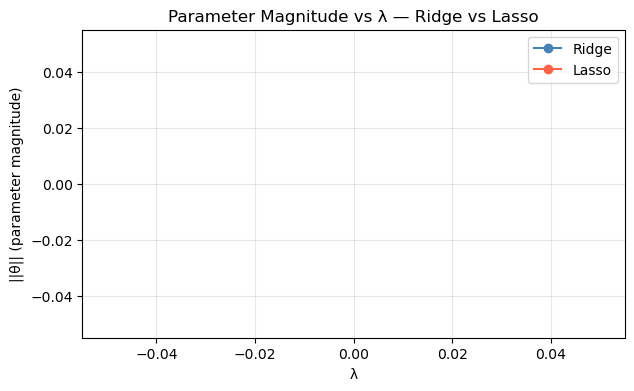

λ=0    → no regularization, largest parameters, likely overfit
λ=0.1  → moderate shrinkage, better generalization
λ=10   → heavy shrinkage, underfitting
Ridge  → shrinks all params toward 0, never exactly 0
Lasso  → drives some params exactly to 0 (feature selection)


In [10]:
# Ridge vs Lasso — parameter magnitude comparison
ridge_norms, lasso_norms = [], []

for lam in lambdas:
    th_r, _ = gradient_descent_ridge(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    th_l, _ = gradient_descent_lasso(X_tr_poly, y_train_s, lr=0.005, iters=2000, lam=lam)
    ridge_norms.append(np.linalg.norm(th_r[1:]))
    lasso_norms.append(np.linalg.norm(th_l[1:]))

plt.figure(figsize=(7, 4))
plt.plot(lambdas, ridge_norms, 'o-', color='steelblue', label='Ridge')
plt.plot(lambdas, lasso_norms, 'o-', color='tomato',    label='Lasso')
plt.xlabel('λ')
plt.ylabel('||θ|| (parameter magnitude)')
plt.title('Parameter Magnitude vs λ — Ridge vs Lasso')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('λ=0    → no regularization, largest parameters, likely overfit')
print('λ=0.1  → moderate shrinkage, better generalization')
print('λ=10   → heavy shrinkage, underfitting')
print('Ridge  → shrinks all params toward 0, never exactly 0')
print('Lasso  → drives some params exactly to 0 (feature selection)')

In [11]:
# 5-Fold Cross Validation to find best lambda
lambda_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
kf          = KFold(n_splits=5, shuffle=True, random_state=42)
degree_cv   = 4
cv_errors   = []

print(f"{'Lambda':<10} {'CV Error (avg)':>16}")
print('-'*28)

for lam in lambda_grid:
    fold_errors = []
    for train_idx, val_idx in kf.split(X_train_s):
        Xtr  = poly_features(X_train_s[train_idx], degree_cv)
        Xval = poly_features(X_train_s[val_idx],   degree_cv)
        ytr  = y_train_s[train_idx]
        yval = y_train_s[val_idx]
        theta, _ = gradient_descent_ridge(Xtr, ytr, lr=0.005, iters=1000, lam=lam)
        fold_errors.append(mse(yval, Xval @ theta))
    avg_err = np.mean(fold_errors)
    cv_errors.append(avg_err)
    print(f"{lam:<10} {avg_err:>16.5f}")

best_lam = lambda_grid[np.argmin(cv_errors)]
print(f"\nBest λ = {best_lam}")

Lambda       CV Error (avg)
----------------------------
0.0001                  nan
0.001                   nan
0.01                    nan
0.1                     nan
1                       nan
10                      nan

Best λ = 0.0001


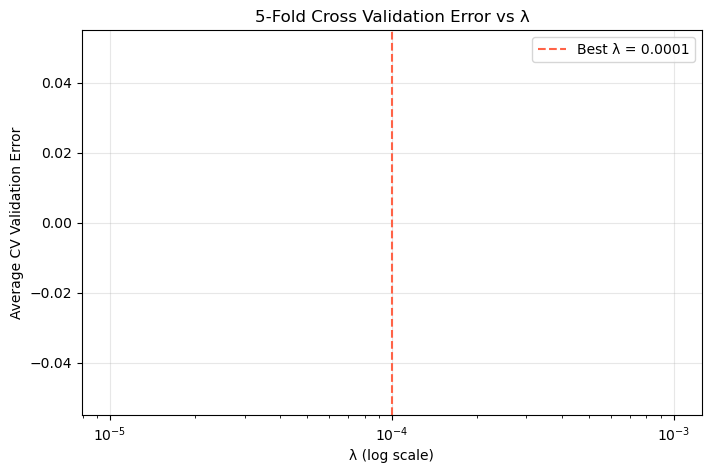

In [12]:
# Validation error vs lambda (log scale)
plt.figure(figsize=(8, 5))
plt.semilogx(lambda_grid, cv_errors, 'o-', color='steelblue', linewidth=2)
plt.axvline(best_lam, color='tomato', linestyle='--', label=f'Best λ = {best_lam}')
plt.xlabel('λ (log scale)')
plt.ylabel('Average CV Validation Error')
plt.title('5-Fold Cross Validation Error vs λ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Retrain on full training data with best lambda
X_full_poly = poly_features(X_train_s, degree_cv)
X_test_poly = poly_features(X_test_s,  degree_cv)

best_theta, _ = gradient_descent_ridge(
    X_full_poly, y_train_s, lr=0.005, iters=2000, lam=best_lam
)

train_loss = mse(y_train_s, X_full_poly @ best_theta)
test_loss  = mse(y_test_s,  X_test_poly  @ best_theta)

print(f'Best λ          : {best_lam}')
print(f'Final Train MSE : {train_loss:.5f}')
print(f'Final Test  MSE : {test_loss:.5f}')

Best λ          : 0.0001
Final Train MSE : nan
Final Test  MSE : nan


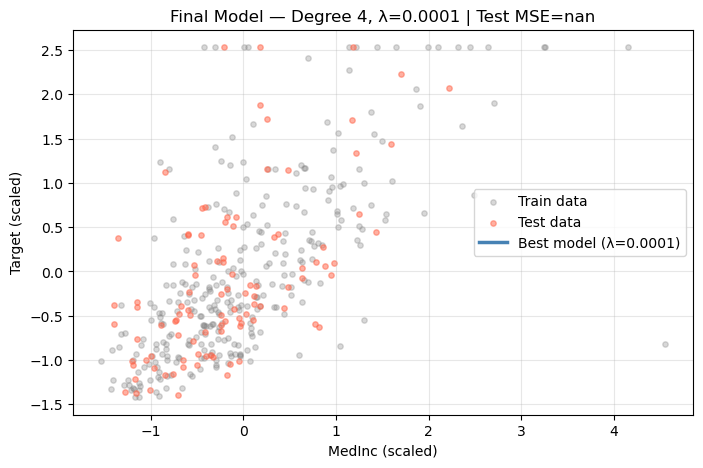

In [14]:
# Final model curve
x_line = np.linspace(X_train_s.min(), X_train_s.max(), 300).reshape(-1, 1)
y_line = poly_features(x_line, degree_cv) @ best_theta

plt.figure(figsize=(8, 5))
plt.scatter(X_train_s[:300], y_train_s[:300], alpha=0.3, s=15, color='gray',   label='Train data')
plt.scatter(X_test_s[:100],  y_test_s[:100],  alpha=0.5, s=15, color='tomato', label='Test data')
plt.plot(x_line, y_line, color='steelblue', linewidth=2.5, label=f'Best model (λ={best_lam})')
plt.xlabel('MedInc (scaled)')
plt.ylabel('Target (scaled)')
plt.title(f'Final Model — Degree {degree_cv}, λ={best_lam} | Test MSE={test_loss:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()